# Two-level atom in the presence of an external field

Consider a non-degenerate two-level atom $(\ket{0},\ket{1})$ subjected to a classical, monochromatic (frequency $\omega_f$) and linearly polarized electric field. Without loss of generality, we choose the $x$ axis as the polarization direction and write the field as
$$\vec{\mathcal{E}} = (\mathcal{E}_0 \cos(\omega_f t)0,0) 
$$ 

The Hamiltonian takes the form 
$$ \hat H = \frac{\hbar\omega_a}{2} \hat\sigma_z + 2\hbar(g\hat\sigma_+ + g^* \hat\sigma_-)\cos(\omega_f t) \quad \text{(Rabi semiclassical Hamiltonian)}
$$
where
* $\omega_a = (E_1-E_0)/\hbar$ is the transition frequency of the atom.
* $g = - \frac{e\mathcal{E}_0}{2\hbar} \bra{1}\hat x\ket{0}$ is the coupling constant between the atom and the field. In practice, it defines the time scale of the system's evolution.

*Note:* Without loss of generality, we will consider a real $g$.

## Solution in the rotated frame

To simplify the Schrödinger equation, it is convenient to work in a rotated frame
$$\ket{\psi(t)}_R = e^{i\frac{\omega_f t}{2}\hat \sigma_z} \ket{\psi(t)} = c_g(t)\ket{g} + c_e(t)\ket{e} 
$$
resulting in 
$$ i\frac{d c_e}{dt} = \frac{\Delta}{2}c_e + g(1+e^{2i\omega_{f} t})c_g \\[4pt]
i\frac{d c_g}{dt} = -\frac{\Delta}{2}c_g + g^*(1+e^{-2i\omega_{f} t})c_e 
$$
where 
* $\Delta = \omega_a - \omega_f$ is the detuning parameter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection


In [ ]:
def Rabi_trayectory(omega_f,delta,initial_state=[1.0 + 0.0j, 0.0 + 0.0j],t_span=None):

    if t_span is None:
        rwa_period = np.pi / np.sqrt(1.0 + delta**2)
        t_span = (0.0, rwa_period)

    tau_eval = np.linspace(t_span[0], t_span[1], 1000)

    def rabi_semiclassical(tau, amplitudes):
        c_g, c_e = amplitudes

        dc_g_dtau = (
            -1j * delta * c_g
            - 1j * (1.0 + np.exp(-2j * omega_f * tau)) * c_e
        )

        dc_e_dtau = (
            1j * delta * c_e
            - 1j * (1.0 + np.exp(2j * omega_f * tau)) * c_g
        )

        return [dc_g_dtau, dc_e_dtau]

    solution = solve_ivp(
        rabi_semiclassical,
        t_span=t_span,
        y0=np.asarray(initial_state, dtype=complex),
        t_eval=tau_eval,
        method="RK45",
        rtol=1e-9,
        atol=1e-11,
    )

    if not solution.success:
        raise RuntimeError(
            f"Numerical integration failed: {solution.message}"
        )

    c_g = solution.y[0]
    c_e = solution.y[1]

    return solution.t, c_g, c_e

## Excitated-state probability evolution


In [ ]:
# Model parameters in g units
omega_f = [10,30,100]  # Laser frequency
delta = [0,0.5,1,2,5]     # Detuning 

c_sol = []
# System of differential equations
for i in range(len(omega_f)):
    c_sol_deltas = []
    for j in range(len(delta)):
        # Initial conditions
        # Time interval in 1/g units
        t_span = (0.0, 2*np.pi)
        # Extract results
        t, c_g, c_e = Rabi_trayectory(omega_f[i],delta[j],t_span= t_span)
        c_sol_deltas.append([c_g,c_e])
    c_sol.append(c_sol_deltas)
c_sol = np.array(c_sol)
    

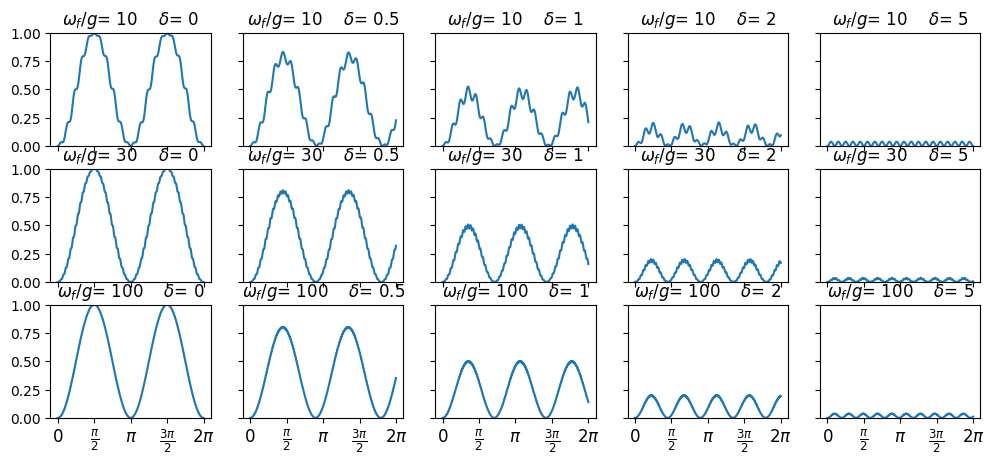

In [ ]:
labels =  [[rf'$\omega_f/g$= {omega_fi}    $\delta$= {deltaj}' for deltaj in delta ] for omega_fi in omega_f]

fig, axes = plt.subplots(nrows=len(omega_f), ncols=len(delta), figsize=(12, 5))


for i in range(len(omega_f)):
    for j in range(len(delta)):
        P_e = np.abs(c_sol[i,j,1])**2
        
        axes[i,j].plot(t, P_e)
        #axes[i,j].xlabel(r'Adimensional time $gt$')
        #axes[i,j].ylabel(r'excited state population $p_e$')

        tick_positions = np.arange(0,5*np.pi/2, np.pi/2)
        tick_labels = ['$0$', r'$\frac{\pi}{2}$', r'$\pi$',r'$\frac{3\pi}{2}$', r'$2\pi$']
        axes[i, j].set_xticks(tick_positions)
        axes[i, j].set_xticklabels(tick_labels, fontsize=12)
        axes[i, j].set_title(labels[i][j])
        axes[i,j].set_ylim(0, 1)
        

for ax in fig.get_axes():
    ax.label_outer()

plt.savefig("Figures/semiclassical-rabi-oscilation.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Bloch Sphere Evolution

In [14]:
def bloch_xyz(c1, c0):
    x = 2 * np.real(c1 * np.conj(c0))
    y = 2 * np.imag(c1 * np.conj(c0))
    z = np.abs(c1)**2 - np.abs(c0)**2
    return x, y, z

def bloch_sphere(ax, alpha=0.15):
    # Draw sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 50)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(
        x, y, z,
        color='lightblue', alpha=alpha,
        edgecolor='gray', linewidth=0.1, shade=True
    )

    # Draw guide circles
    theta = np.linspace(0, 2 * np.pi, 100)
    # Equator
    ax.plot(np.cos(theta), np.sin(theta), 0 * theta, 'gray',
            alpha=0.3, linewidth=0.8, linestyle='--')
    # XZ meridian
    ax.plot(np.cos(theta), 0 * theta, np.sin(theta), 'gray',
            alpha=0.3, linewidth=0.8, linestyle='--')
    # YZ meridian
    ax.plot(0 * theta, np.cos(theta), np.sin(theta), 'gray',
            alpha=0.3, linewidth=0.8, linestyle='--')
    
    # Coordinate axes
    axis_length = 1.3
    ax.plot([-axis_length, axis_length], [0, 0], [0, 0],
            'k-', linewidth=1.5, alpha=0.6)
    ax.plot([0, 0], [-axis_length, axis_length], [0, 0],
            'k-', linewidth=1.5, alpha=0.6)
    ax.plot([0, 0], [0, 0], [-axis_length, axis_length],
            'k-', linewidth=1.5, alpha=0.6)

    # Axis labels
    offset = 1.5
    ax.text(offset, 0, 0, r'$\langle\hat{\sigma}_x\rangle$',
            fontsize=14, ha='center')
    ax.text(0, offset, 0, r'$\langle\hat{\sigma}_y\rangle$',
            fontsize=14, ha='center')
    ax.text(0, 0, offset, r'$\langle\hat{\sigma}_z\rangle$',
            fontsize=14, ha='center')
    
    # Basis states
    ax.text(0, 0, 1.3, r'$|1\rangle$', fontsize=16, color='darkblue',
            fontweight='bold', ha='center')
    ax.text(0, 0, -1.3, r'$|0\rangle$', fontsize=16, color='darkred',
            fontweight='bold', ha='center')
    
    # View configuration
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.view_init(elev=20, azim=45)

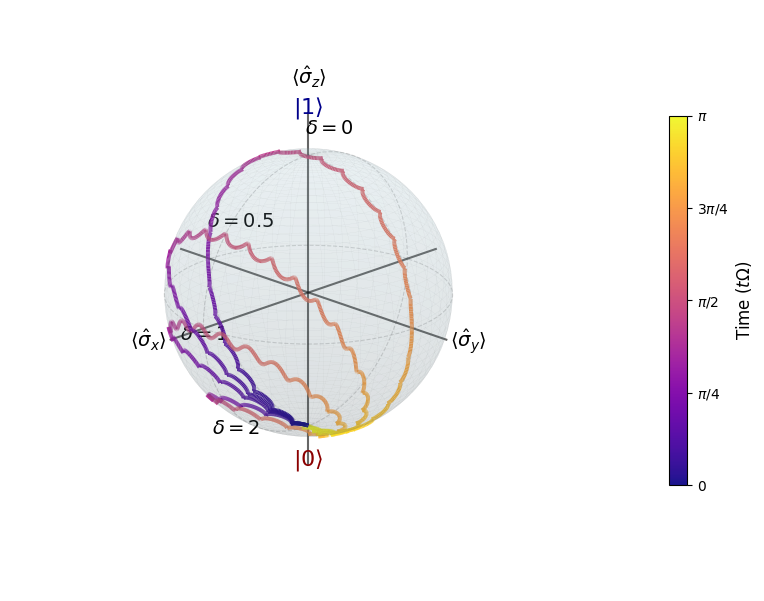

In [15]:
delta = [0,0.5,1,2] 
omega_f = 30

# Plot in the rotating frame
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
bloch_sphere(ax, alpha=0.10)

for i in range(len(delta)):
    sol = Rabi_trayectory(omega_f,delta[i])

    time, c_g, c_e = np.real(sol[0]*np.sqrt(1+delta[i]**2)),sol[1],sol[2]  
    x,y,z = bloch_xyz(c_e, c_g)


    points = np.array([x, y, z]).T.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=time.min(), vmax=time.max())
    cmap = plt.get_cmap("plasma")

    lc = Line3DCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(time[:-1])
    lc.set_linewidth(2.8)
    lc.set_alpha(0.95)
    ax.add_collection3d(lc)

# --- Add Label for each line ---
    # Places the label at the end point of the trajectory
    label_text = f'$\\delta = {delta[i]}$'
    middle_index = int(len(time)/2)
    ax.text(x[middle_index]*1.2, y[middle_index]*1.2, z[middle_index]*1.2, label_text, fontsize=14, 
            verticalalignment='center', horizontalalignment='left')


# --- Add Colorbar ---
# Using shrink and pad arguments to prevent the colorbar from overlapping the 3D plot
cbar = fig.colorbar(lc, ax=ax, shrink=0.6, pad=0.1)

# Set tick locations at multiples of pi/4
tick_locations = np.arange(0, np.pi + 0.1, np.pi/4)
cbar.set_ticks(tick_locations)

# Set custom LaTeX labels
cbar.set_ticklabels(['$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
cbar.set_label(r'Time ($t\Omega$)', fontsize=12)
plt.savefig("bloch-sphere.pdf", format="pdf", bbox_inches="tight")

plt.show()



## Rotating frame vs laboratory frame

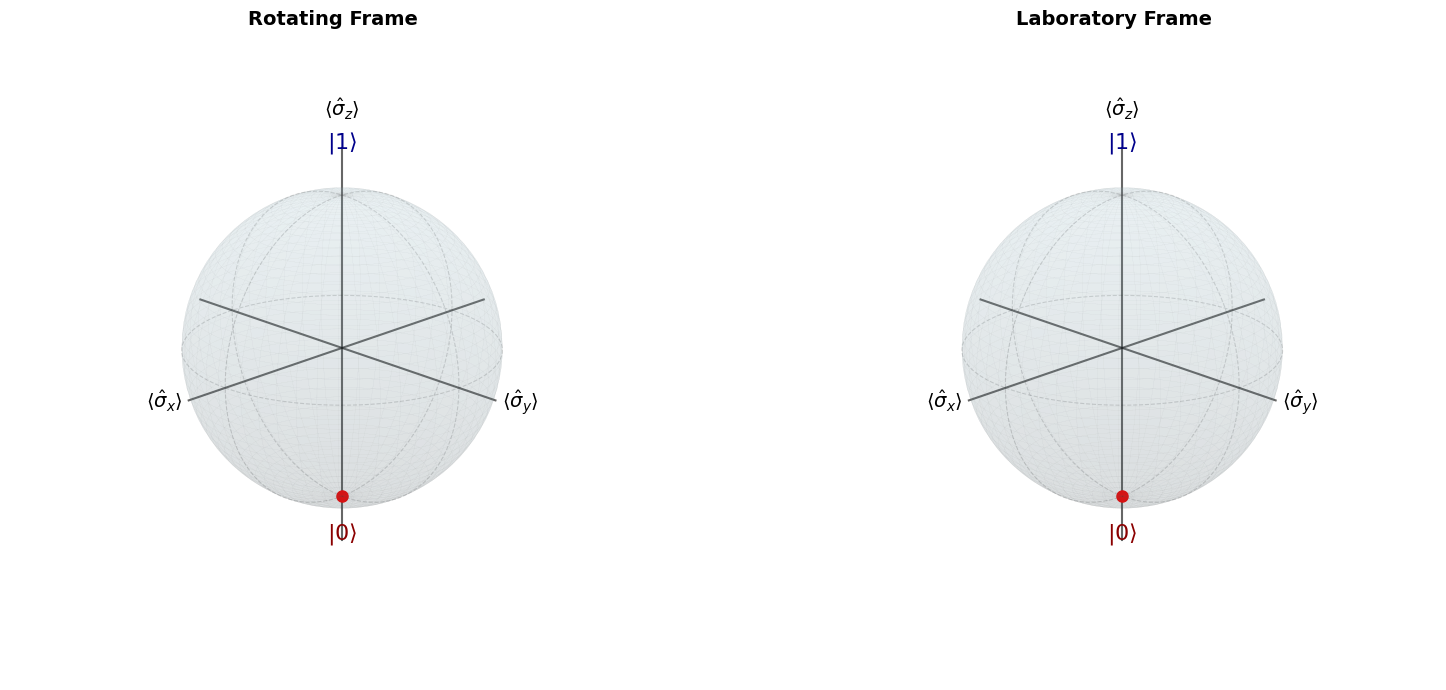

In [ ]:
from matplotlib.animation import FuncAnimation

# Create figure with two subplots (rotating frame and laboratory)
fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Configure Bloch spheres
bloch_sphere(ax1, alpha=0.10)
bloch_sphere(ax2, alpha=0.10)

ax1.set_title('Rotating Frame', fontsize=14, fontweight='bold')
ax2.set_title('Laboratory Frame', fontsize=14, fontweight='bold')

# Trajectory vectors in rotating frame
omega_f = 30
delta = 0.5
initial_state = [1.0 + 0.0j, 0.0 + 0.0j]
t, c_g, c_e = Rabi_trayectory(omega_f,delta,initial_state)
x_rot, y_rot, z_rot = bloch_xyz(c_e, c_g)

# Trajectory vectors in laboratory frame
x_lab, y_lab, z_lab = bloch_xyz(c_e * np.exp(-1j * omega_f/2 * t), c_g * np.exp(1j * omega_f/2 * t))

# Lines for the trajectories
line1, = ax1.plot([], [], [], 'b-', linewidth=2, alpha=0.7)
point1, = ax1.plot([], [], [], 'ro', markersize=8)

line2, = ax2.plot([], [], [], 'b-', linewidth=2, alpha=0.7)
point2, = ax2.plot([], [], [], 'ro', markersize=8)

# Number of points to show in the trajectory
trail_length = 50

def animate(frame):
    # Rotating frame
    start_idx = max(0, frame - trail_length)
    line1.set_data(x_rot[start_idx:frame], y_rot[start_idx:frame])
    line1.set_3d_properties(z_rot[start_idx:frame])
    point1.set_data([x_rot[frame]], [y_rot[frame]])
    point1.set_3d_properties([z_rot[frame]])
    
    # Laboratory frame
    line2.set_data(x_lab[start_idx:frame], y_lab[start_idx:frame])
    line2.set_3d_properties(z_lab[start_idx:frame])
    point2.set_data([x_lab[frame]], [y_lab[frame]])
    point2.set_3d_properties([z_lab[frame]])
    
    return line1, point1, line2, point2

# Create animation
anim = FuncAnimation(fig, animate, frames=len(t), interval=20, blit=True, repeat=True)
plt.tight_layout()
plt.show()

# Guardar la animación como GIF
anim.save('bloch_sphere_animation.gif', writer='pillow', fps=30)

## Solution with rotating wave aproximation
$$ i\frac{d c_e}{dt} = \frac{\Delta}{2}c_e + gc_g \\[4pt]
i\frac{d c_g}{dt} = -\frac{\Delta}{2}c_g + gc_e 
$$
$$ P_e(t) = \frac{1}{1+\delta^2}\,\sin^2\!\big(g\,t\sqrt{1+\delta^2}\big)$$
$$P_{e,\max}(\delta)=\frac{1}{1+\delta^2}$$

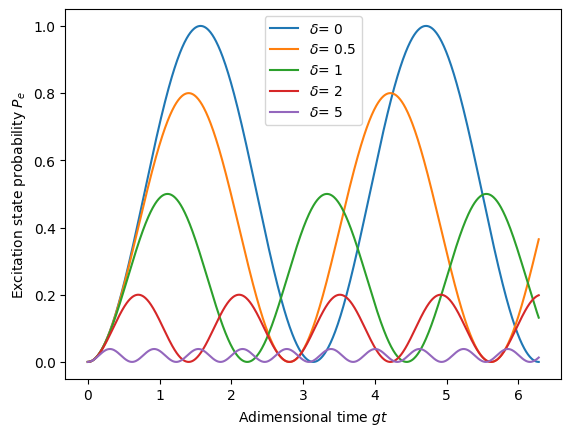

In [16]:
delta = [0,0.5,1,2,5]
time = np.linspace(0,2*np.pi,1000) # Time inteval in 1/g units
p1 = np.array([1/(1+deltai**2)*np.sin(time*np.sqrt(1+deltai**2))**2 for deltai in delta])

labels =  [rf'$\delta$= {deltai}'    for deltai in delta]

for i in range(len(delta)):
    plt.plot(time,p1[i],label=labels[i])

plt.xlabel(r'Adimensional time $gt$')
plt.ylabel(r'Excitation state probability $P_e$')
plt.legend()
plt.savefig("semiclassical-rabi-oscilations-RWA.pdf", format="pdf", bbox_inches="tight")
plt.show()


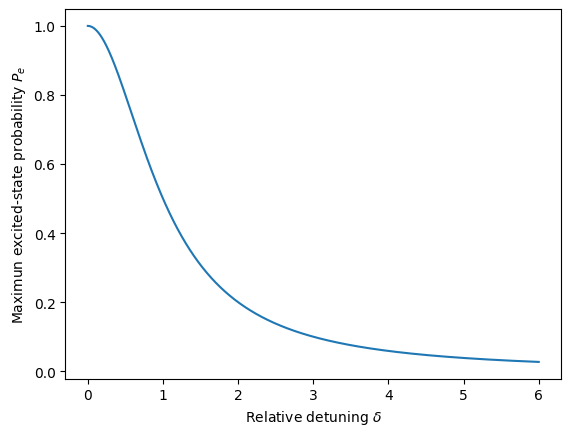

In [17]:
delta = np.linspace(0,6,1000)
p1_max = 1/(1+delta**2)
plt.plot(delta,p1_max)
plt.xlabel(r"Relative detuning $\delta$")
plt.ylabel(r"Maximun excited-state probability $P_e$")
plt.savefig("max-p-excited-state-RWA.pdf", format="pdf", bbox_inches="tight")
plt.show()


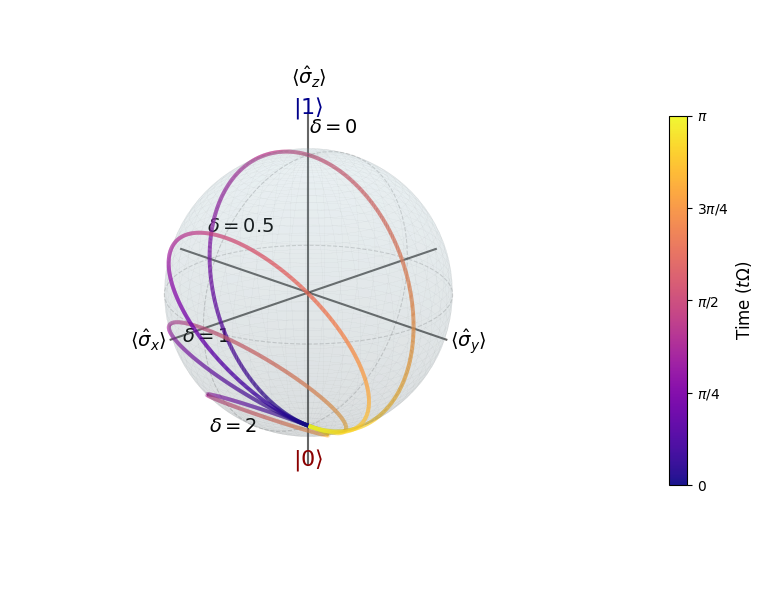

In [18]:
delta = [0,0.5,1,2] 
time = np.linspace(0,np.pi,1000) # time interval in 1/Omega units


# Plot in the rotating frame
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
bloch_sphere(ax, alpha=0.10)

for i in range(len(delta)):
    # Trajectory on the Bloch sphere
    x = 2*delta[i]/(1+delta[i]**2)*np.sin(time)**2
    y = - 1/np.sqrt(1+delta[i]**2)*np.sin(2*time)
    z = -1 + 2/(1+delta[i]**2)*np.sin(time)**2

    points = np.array([x, y, z]).T.reshape(-1, 1, 3)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(vmin=time.min(), vmax=time.max())
    cmap = plt.get_cmap("plasma")

    lc = Line3DCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(time[:-1])
    lc.set_linewidth(2.8)
    lc.set_alpha(0.95)
    ax.add_collection3d(lc)

# --- Add Label for each line ---
    # Places the label at the end point of the trajectory
    label_text = f'$\\delta = {delta[i]}$'
    middle_index = int(len(time)/2)
    ax.text(x[middle_index]*1.2, y[middle_index]*1.2, z[middle_index]*1.2, label_text, fontsize=14, 
            verticalalignment='center', horizontalalignment='left')
# --- Add Colorbar ---
# Using shrink and pad arguments to prevent the colorbar from overlapping the 3D plot
cbar = fig.colorbar(lc, ax=ax, shrink=0.6, pad=0.1)

# Set tick locations at multiples of pi/4
tick_locations = np.arange(0, np.pi + 0.1, np.pi/4)
cbar.set_ticks(tick_locations)

# Set custom LaTeX labels
cbar.set_ticklabels(['$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'])
cbar.set_label(r'Time ($t\Omega$)', fontsize=12)

plt.savefig("bloch-sphere-RWA.pdf", format="pdf", bbox_inches="tight")
plt.show()


## RWA Error


In [42]:
def max_P_e_difference(omega_f,delta):
    t, c_g, c_e = Rabi_trayectory(omega_f,delta)
    Omega = np.sqrt(1+delta**2) 
    P_e_exact = np.abs(c_e)**2
    P_e_rwa = 1/(1+delta**2)*np.sin(t*Omega)**2
    max_difference = np.max(np.abs(P_e_exact-P_e_rwa))
    return max_difference

omega_f = np.linspace(5,100,30)
delta = np.linspace(0,5,30)

differences = np.array([[max_P_e_difference(omega_fi,deltaj) for deltaj in delta] for omega_fi in omega_f] )


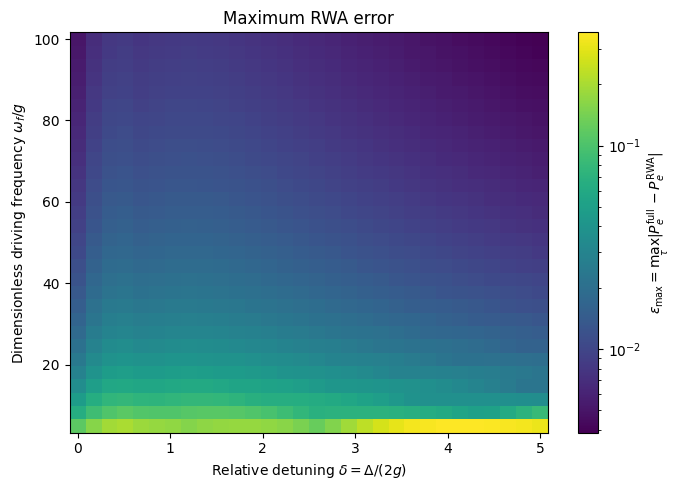

In [ ]:
from matplotlib.colors import LogNorm

positive_differences = differences[differences > 0]

fig, ax = plt.subplots(figsize=(7, 5))

heatmap = ax.pcolormesh(
    delta,
    omega_f,
    differences,
    shading="auto",
    cmap="viridis",
    norm=LogNorm(
        vmin=positive_differences.min(),
        vmax=differences.max(),
    ),
)

colorbar = fig.colorbar(heatmap, ax=ax)
colorbar.set_label(
    r"$\epsilon_{\max}"
    r"=\max_{\tau}|P_e^{\mathrm{full}}-P_e^{\mathrm{RWA}}|$"
)

ax.set_xlabel(r"Relative detuning $\delta=\Delta/(2g)$")
ax.set_ylabel(r"Dimensionless driving frequency $\omega_f/g$")
ax.set_title("Maximum RWA error")

fig.tight_layout()
plt.savefig("maximun-rwa-error.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [ ]:
# Model parameters in g units
omega_f = [10,30,100]  # Laser frequency
delta = [0,0.5,1,2,5]     # Detuning 

c_sol = []
# System of differential equations
for i in range(len(omega_f)):
    c_sol_deltas = []
    for j in range(len(delta)):
        # Initial conditions
        initial_state = [1.0 + 0.0j, 0.0 + 0.0j]
        # Time interval in 1/g units
        t_span = (0.0, 2*np.pi)
        # Extract results
        t, c_g, c_e = Rabi_trayectory(omega_f[i],delta[j],initial_state,t_span= t_span)
        c_sol_deltas.append([c_g,c_e])
    c_sol.append(c_sol_deltas)
c_sol = np.array(c_sol)



labels =  [[rf'$\omega_f/g$= {omega_fi}    $\delta$= {deltaj}' for deltaj in delta ] for omega_fi in omega_f]

fig, axes = plt.subplots(nrows=len(omega_f), ncols=len(delta), figsize=(12, 5))


for i in range(len(omega_f)):
    for j in range(len(delta)):
        P_e = np.abs(c_sol[i,j,1])**2
        
        axes[i,j].plot(t, P_e)
        #axes[i,j].xlabel(r'Adimensional time $gt$')
        #axes[i,j].ylabel(r'excited state population $p_e$')

        tick_positions = np.arange(0,5*np.pi/2, np.pi/2)
        tick_labels = ['$0$', r'$\frac{\pi}{2}$', r'$\pi$',r'$\frac{3\pi}{2}$', r'$2\pi$']
        axes[i, j].set_xticks(tick_positions)
        axes[i, j].set_xticklabels(tick_labels, fontsize=12)
        axes[i, j].set_title(labels[i][j])
        axes[i,j].set_ylim(0, 1)
        

for ax in fig.get_axes():
    ax.label_outer()

plt.savefig("semiclassical-rabi-oscilation.pdf", format="pdf", bbox_inches="tight")
plt.show()
    